# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [142]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

import time

import pickle

from sklearn import model_selection, metrics, preprocessing
from sklearn import cluster

import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

cm = 1./2.54
path_print = 'Figures/explore/'

## Paramètres graphiques et fonctions utiles

In [143]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


set_theme()
del set_theme

## Chargement des données

Affichage de l'arborescence

In [144]:
def print_listdir( path=None, level=0, exclude=[] ) :
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val):
            print_listdir( path + val + '/', level+1 )

print_listdir( exclude=['.venv', '.venv2', 'ressources', 'devel'] )

 Figures
 |- explore
 |- |- Frequence.pdf
 |- |- Montant.pdf
 |- |- N_orders_vs_time.pdf
 |- |- Recence.pdf
 |- |- delivery_delay.pdf
 |- |- order_status.pdf
 |- |- pair_plot.pdf
 |- |- pair_plot.png
 |- |- payment_type.pdf
 |- |- review_score.pdf
 data
 |- cleaned
 |- |- iteration_tsne_RFM.pickle
 |- |- iteration_tsne_RFM_delay.pickle
 |- |- iteration_tsne_RFM_review_score.pickle
 |- |- iteration_tsne_RFM_type_payment.pickle
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olis

Chargement

In [145]:
path = 'data/source/'

filenames = ['customers', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = { filename: pd.read_csv( path + f'olist_{filename}_dataset' + '.csv' ) for filename in filenames }
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv( path + filename + '.csv')

path_save = 'data/cleaned/'

Chaque jeu de données est relié à un ou plusieurs autres jeux à partir d'une variable. En regardant l'image ci-dessous, le dataset "`orders`" est lié aux dataset "`order_payments`", "`oder_reviews`" et "`order_items`" par la variable "`order_id`", ainsi qu'au dataset "`customer`" (order_customer dans l'image) par la variable "`customer_id`".

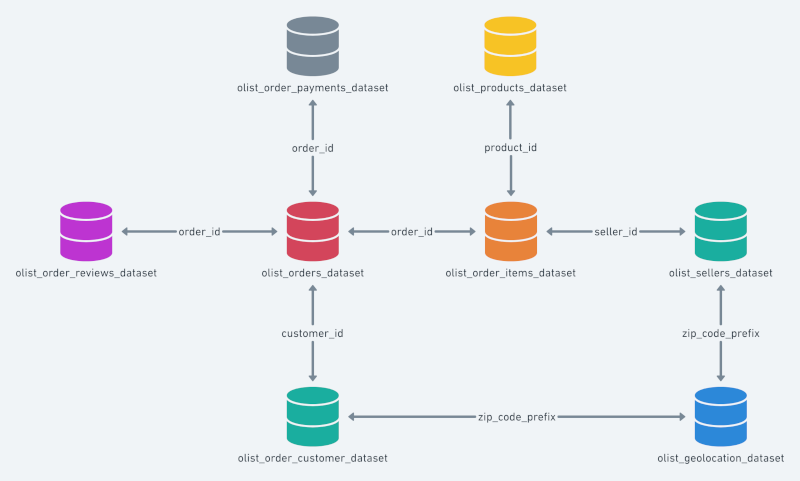

In [146]:
for filename, df_tmp in dfs.items():
    # print(filename)
    display( df_tmp.sample(5).style.set_caption(filename) )
    print('\n\n')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
49666,8aed5e76471af1470607b27d670075a6,3995ee80edd6d037333599d4da968829,45655,ilheus,BA
21292,2e733322a259241fb19545190024661d,4e756b60c02fc0445da510e7fe4a08ac,80520,curitiba,PR
58151,a7d55a3890b6930701664ffe5cf43967,2fe46c401749e9e36339f1eee4f16396,48904,juazeiro,BA
17735,70f95a47532d0a1ffd3b15302f61a1bf,34b6869483f9c2ebecee59d3be7f6416,38401,uberlandia,MG
2964,3949edfef86218762911d9a16c513011,ecd8c8b41a6a11e74f9ce6e5bbb3e995,76550,porangatu,GO


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
10850,fd79fe34d2fd6389d56e726bfc0bff4f,6686fe53ca93846b096f9c1885fce063,delivered,2018-05-05 17:40:39,2018-05-08 04:35:34,2018-05-08 14:53:00,2018-05-09 19:48:40,2018-05-18 00:00:00
59459,5ea01f5660c8d089b604b2d1ddaab334,6a6080efe1fe4bd44070465cb7375c5c,delivered,2017-08-14 18:20:04,2017-08-15 03:55:22,2017-08-15 18:10:43,2017-08-16 16:38:45,2017-08-25 00:00:00
16423,d3cb6dffcf96cec441e9f4bf3367d133,1dd1f1efccf6a33c8dc013fa534e8dd0,delivered,2018-02-19 13:26:43,2018-02-20 07:26:54,2018-02-20 19:15:21,2018-03-26 22:18:26,2018-03-20 00:00:00
12265,200af1dfa6b1bbe29adcddac8ed2a00b,11a5f3092fc00cabdee343a56943d40b,delivered,2018-01-15 16:56:30,2018-01-16 04:31:01,2018-01-17 17:24:48,2018-01-31 21:06:53,2018-02-06 00:00:00
69453,2524a4278af338cc4ba22f64a10d5798,766937eae4ef200d016b8717d52392fe,delivered,2018-04-12 02:17:54,2018-04-12 03:00:46,2018-04-13 18:04:39,2018-05-05 20:31:07,2018-05-11 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
102367,e865720063d35fe789029a6021f2df31,1,651fe753ea1d6ad3d5744c1bffd3d6e1,7178f9f4dd81dcef02f62acdf8151e01,2017-12-11 02:24:32,19.900000,15.100000
73668,a7e2e99e49329dff2ac305e42c7fb59e,1,5aadf21c27e505224812c9b055031c73,077c5fae4bea9500e3737b16f71b9d3a,2017-10-30 03:25:54,5.400000,9.270000
91043,cec04b13070b06e2f7326de94287d60d,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-10 06:35:40,124.990000,11.480000
48679,6ea34077e85038c0ecea08593783a1fd,1,59be0d716996dda6b7d60b3e839efad3,ad420dd0c4f92f8af951ac24b86d0cf5,2018-07-02 19:55:13,160.000000,19.220000
97414,dcf834176dc467316b2e4dbd9544a9b4,1,fecf6223a3494f35362f670e571d2a04,3db66a856d18a9cba7c9241fc5221c50,2017-12-07 18:30:32,69.900000,16.250000


,order_id,payment_sequential,payment_type,payment_installments,payment_value
65043,4eedbea06033407253ea131738b99a5d,1,credit_card,3,68.290000
49761,bea1416bda62c3b5fb9ecdad82621058,1,boleto,1,130.250000
101348,3365749860804a01bf35b50fffcfe842,1,credit_card,1,76.660000
29995,a72d0db4daa2d7a8a1a4a8e499cc2ae5,1,credit_card,5,105.280000
99921,38c61d1bbf5143a8c347ebaa490e234b,3,voucher,1,47.210000


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
26830,ace498a42ad82890f5d6fba13062cac0,19fffb5eab0cb56530a7569759bcf889,4,nan,nan,2017-07-29 00:00:00,2017-08-01 19:05:36
10188,f571c7525470743461cf7da3db9dec76,58cb19858693389b8a5070ce73daa04c,5,nan,nan,2018-04-18 00:00:00,2018-04-19 15:01:08
58133,a87104de04548211cad078b4dd8feaa6,d47a277ee3c0a6d83aac8548c06263cf,5,nan,nan,2017-09-23 00:00:00,2017-09-25 11:01:56
96747,fea4fa6bcfd953b9656d75d0e0218dbd,8304cd42545c641d13b9165c7028c85a,2,nan,nan,2018-01-24 00:00:00,2018-01-25 11:31:36
17106,e0e09e6a07198593f73a3f74e1d9bcd5,b6fbf15260de2095643a4aac7876872c,4,nan,nan,2017-10-27 00:00:00,2017-10-27 22:03:10


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8312,f72ddd64b808244cb34e9e02e9bd92fb,automotivo,47.000000,570.000000,1.000000,3300.000000,35.000000,20.000000,20.000000
510,52a646aa308987e28c375b41081de428,sinalizacao_e_seguranca,53.000000,512.000000,1.000000,325.000000,17.000000,17.000000,17.000000
25461,fdd4f5e099d232bbd0d1fca8eab34172,fashion_bolsas_e_acessorios,29.000000,110.000000,1.000000,200.000000,16.000000,10.000000,15.000000
4412,664fa109c2fdc2f1c8f1ec2b6863fe5c,brinquedos,59.000000,377.000000,5.000000,350.000000,28.000000,20.000000,24.000000
18527,259a24ea2a742082c43dd2f5ce116b52,bebes,28.000000,381.000000,1.000000,1454.000000,24.000000,22.000000,20.000000


,seller_id,seller_zip_code_prefix,seller_city,seller_state
2886,17908cf9b444ee34047cadd5c0f4a516,75124,anapolis,GO
193,5abb8ea023c77787f2c15da891c8d384,89228,joinville,SC
3039,3d49bfdd1b43a7fe169b3740067acc61,39400,montes claros,MG
2876,2b3e4a2a3ea8e01938cabda2a3e5cc79,4733,sao paulo,SP
324,8501d82f68d23148b6d78bb7c4a42037,89031,blumenau,SC


,product_category_name,product_category_name_english
56,eletrodomesticos_2,home_appliances_2
7,utilidades_domesticas,housewares
52,sinalizacao_e_seguranca,signaling_and_security
49,construcao_ferramentas_seguranca,construction_tools_safety
65,dvds_blu_ray,dvds_blu_ray


On va s'intéresser à 4 datasets : "`customers`", "`orders`", "`order_payment`" et "`order_reviews`".

In [147]:
df = dfs['customers']
# print('custormers :', df.shape)
display( df.head().style.set_caption( 'customers') )

df.info()

print('customer_id :', df['customer_id'].value_counts().shape )
print('customer_unique_id :', df['customer_unique_id'].value_counts().shape )

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customer_id : (99441,)
customer_unique_id : (96096,)


In [148]:
df = dfs['orders']
# print('orders :', df.shape)
display( df.head().style.set_caption( 'orders' ) )

df.info()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [149]:
df = dfs['order_payments']
# print('order_payments :', df.shape)
display( df.head().style.set_caption( 'order_payments' ) )

df.info()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.330000
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.390000
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.710000
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.780000
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.450000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [150]:
df = dfs['order_reviews']
# print('order_payments :', df.shape)
display( df.head().style.set_caption('order_reviews') )

df.info()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,nan,nan,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,nan,nan,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,nan,nan,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,nan,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,nan,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


## Fusion des dataset d'intérêt

In [151]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge( dfs['order_payments'], how='left', on='order_id' )
df_merged = df_merged.merge( dfs['order_reviews'], how='left', on='order_id' )

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
30695,1cd399dcea276c15247818674bb83c63,f993b0045d93d3f6c49417bc141e3161,delivered,2017-06-19 11:56:27,2017-06-20 10:35:23,2017-06-27 10:51:30,2017-07-03 14:51:21,2017-07-11 00:00:00,1271e59bf9337e70d4ca21fae84832a3,5050,sao paulo,SP,1.0,boleto,1.0,63.50,abee8ba52893c9d62bdfb0013a3b4868,3.0,NaN,"Achei o produto inferior ao que vi no site, ma...",2017-07-04 00:00:00,2017-07-05 01:15:04
104062,6bc3c200db7e637a78b05d8984dcf66f,49c01eb0774fa3c20b2b4aa1b1682b4b,delivered,2017-02-03 11:05:24,2017-02-04 11:10:13,2017-02-06 10:27:30,2017-02-13 11:38:52,2017-03-22 00:00:00,a4ee69b44b706be22ef7dc61d65606fc,7172,guarulhos,SP,2.0,voucher,1.0,126.29,5a7721d6e1524c0d1b3dd3f08e2f63c0,5.0,NaN,NaN,2017-02-14 00:00:00,2017-02-20 14:45:49
84013,d3433b37aa2f57a56e8c97c455ac6ed8,1d51ab9a70ead50582098a67457ccd8a,delivered,2017-12-02 18:38:46,2017-12-02 18:57:15,2017-12-06 16:35:20,2017-12-14 22:04:35,2018-01-09 00:00:00,3e07cafe9109c34edd3ccca457aa0adf,6950,juquitiba,SP,1.0,credit_card,5.0,162.68,06826af34f7a2fb4440cf794a7bfbaf9,3.0,NaN,Não tinham o produto que comprei...tive que tr...,2017-12-15 00:00:00,2017-12-18 00:21:00
92702,3eb18430be4502566fc9ac46bdce44b1,46a6fa15b9f59db51c19aab8f0312bac,delivered,2018-03-07 14:46:20,2018-03-09 02:10:27,2018-03-20 16:32:54,2018-04-03 12:16:22,2018-04-10 00:00:00,061978c4a1b3012b567a5d51eefd1157,17017,bauru,SP,1.0,boleto,1.0,227.16,89940b2d6f93a712fc2b8e440728e554,5.0,NaN,NaN,2018-04-04 00:00:00,2018-04-04 23:54:11
12516,c01386219d1d09bb78eab2fc5347a149,83617c8843d329aa9e284869b0cb1926,delivered,2017-03-31 14:54:12,2017-03-31 15:05:10,2017-04-03 14:35:47,2017-04-19 16:08:36,2017-05-15 00:00:00,f28e57ccfa94a285a9ef69407f0df444,68553,redencao,PA,1.0,credit_card,6.0,159.74,889e44c85b90f4a00b3eccecf3ae794d,5.0,NaN,Produto de qualidade e entrega no prazo correto.,2017-04-20 00:00:00,2017-04-21 16:34:08


Conversion des timestamp

In [152]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

# Analyse des données

## Données brutes

delivered      96.983097
shipped         1.126553
canceled        0.639369
unavailable     0.623098
invoiced        0.314899
processing      0.306285
created         0.004786
approved        0.001914
Name: order_status, dtype: float64

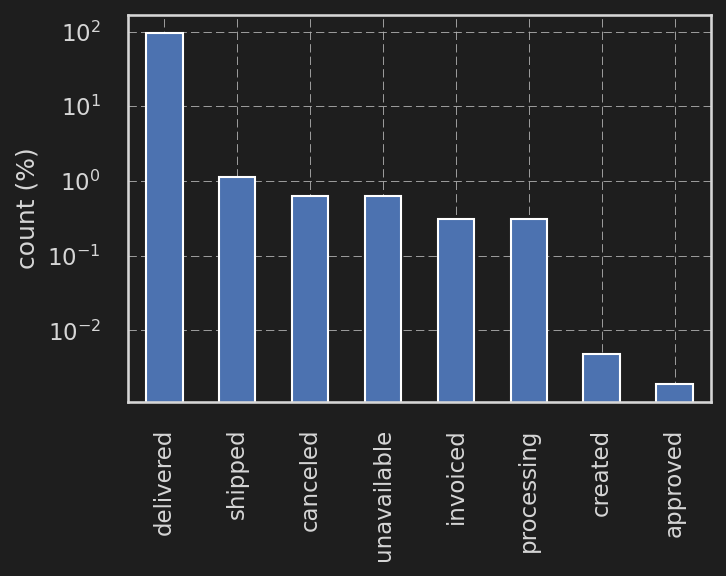

In [153]:
key = 'order_status'
value_counts = 100* ( df_merged[key].value_counts( normalize=True ) )
display( value_counts )

fig, ax = plt.subplots( figsize=(5,4) )
value_counts.plot( kind='bar', logy=True, ax=ax )
ax.set_ylabel('count (%)')

fig.tight_layout()
savefig( fig, path_print + 'order_status' )

In [154]:
df_merged['order_purchase_timestamp'].dt.year.value_counts()

2018    56238
2017    47891
2016      349
Name: order_purchase_timestamp, dtype: int64

Affichage des données temporelles

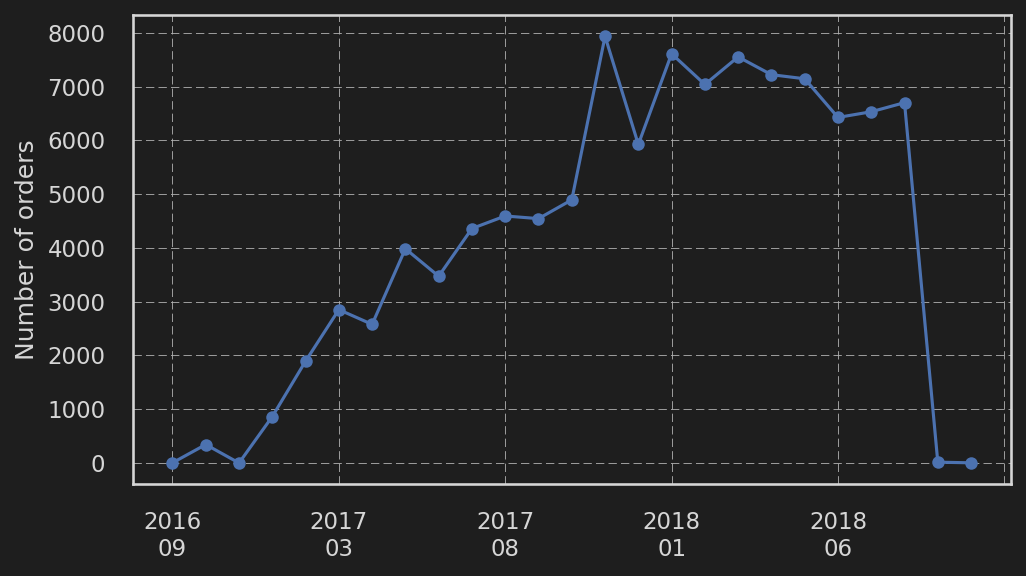

In [155]:
fig, ax = plt.subplots( figsize=(7,4) )
# df_merged['order_purchase_timestamp'].apply(lambda x: x.strftime('%Y\n%m') ).value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
df_merged['order_purchase_timestamp'].dt.strftime('%Y\n%m').value_counts().sort_index().plot(kind='line', ax=ax, style='-o')
ax.set_ylabel( 'Number of orders')
fig.tight_layout()

savefig( fig, path_print + 'N_orders_vs_time' )

In [156]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104478 entries, 0 to 104477
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104478 non-null  object        
 1   customer_id                    104478 non-null  object        
 2   order_status                   104478 non-null  object        
 3   order_purchase_timestamp       104478 non-null  datetime64[ns]
 4   order_approved_at              104302 non-null  datetime64[ns]
 5   order_delivered_carrier_date   102580 non-null  datetime64[ns]
 6   order_delivered_customer_date  101324 non-null  datetime64[ns]
 7   order_estimated_delivery_date  104478 non-null  datetime64[ns]
 8   customer_unique_id             104478 non-null  object        
 9   customer_zip_code_prefix       104478 non-null  int64         
 10  customer_city                  104478 non-null  object        
 11  

In [157]:
df_merged['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

Calcul variables RFM (Récence, Fréquence, Montant)

In [158]:
print( 'customer_id :', df_merged['customer_id'].value_counts().shape ) 
print( 'customer_unique_id :', df_merged['customer_unique_id'].value_counts().shape )


groups = df_merged[['customer_unique_id',
                      'payment_value']].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max() - df_merged['order_purchase_timestamp']).dt.days



groups = groups.groupby( by='customer_unique_id' )

# initial check
# df_model = pd.DataFrame()
# df_model['Recence'] = groups['number_of_days_since_last_order' ].max()
# df_model['Frequence'] = groups['payment_value'].size()
# df_model['Montant'] = groups['payment_value'].sum()
# display( df_model.iloc[18:27,:] )

df_model = groups.agg( {'number_of_days_since_last_order':'max',
                        'customer_unique_id':'count',
                        'payment_value':'sum'} )
df_model.rename( columns={'number_of_days_since_last_order':'Recence',
                    'customer_unique_id':'Frequence',
                    'payment_value':'Montant'}, inplace=True )
# check if correct
# print( np.abs( df_model.values - df_model_2.values ).sum() )

display( df_model.iloc[18:27,:] )


# df_model = df_model.groupby( by='customer_unique_id' ).agg( ['sum', 'size', 'max'] )
# display( df_model.iloc[18:27,:] )

# df_model_2 = pd.DataFrame()
# df_model_2[['montant', 'number_of_orders', 'number_of_days_since_last_order']] = df_model[ [('payment_value','sum'), ('payment_value', 'size'), ('number_of_days_since_last_order', 'max')]]
# df_model_2.iloc[18:27,:]

customer_id : (99441,)
customer_unique_id : (96096,)


,Recence,Frequence,Montant
customer_unique_id,,,
000de6019bb59f34c099a907c151d855,425,1,257.44
000e309254ab1fc5ba99dd469d36bdb4,114,2,78.42
000ec5bff359e1c0ad76a81a45cb598f,57,1,27.75
000ed48ceeb6f4bf8ad021a10a3c7b43,150,1,20.75
000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38
0010a452c6d13139e50b57f19f52e04e,463,1,325.93
0010fb34b966d44409382af9e8fd5b77,226,1,61.80
001147e649a7b1afd577e873841632dd,412,1,212.16
00115fc7123b5310cf6d3a3aa932699e,633,1,76.11


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,19,22,26,29,17,33,23
Frequence,90290,4569,740,256,82,63,31,13,12,8,7,6,4,3,2,2,2,1,1,1,1,1,1
%,93.958,4.755,0.77,0.266,0.085,0.066,0.032,0.014,0.012,0.008,0.007,0.006,0.004,0.003,0.002,0.002,0.002,0.001,0.001,0.001,0.001,0.001,0.001


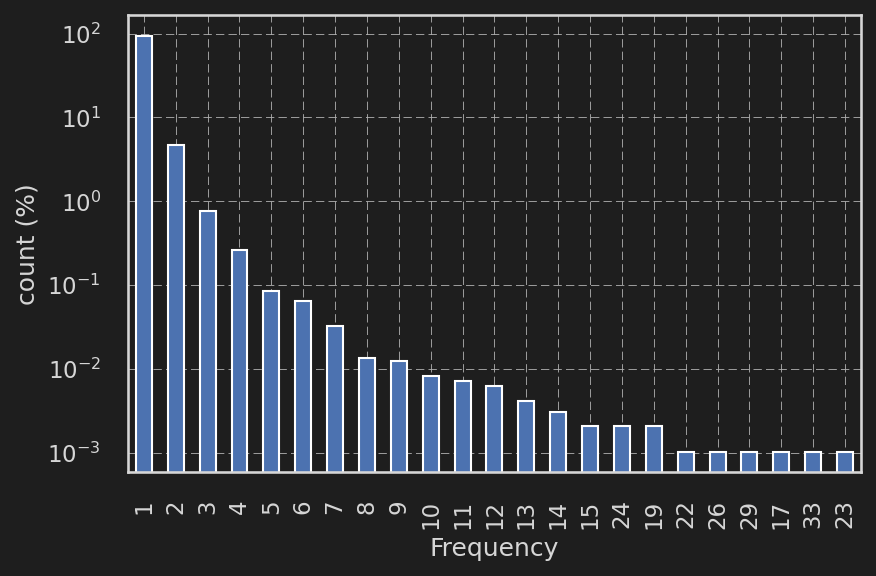

In [159]:
sr_freq = df_model['Frequence'].value_counts( )
df_freq = pd.DataFrame( sr_freq.astype(str) ) # str for display
sr_freq *= 100 / sr_freq.sum()
df_freq['%'] = sr_freq.values.round(3)
display( df_freq.T )


fig, ax = plt.subplots( figsize=(6,4) )
sr_freq.plot( kind='bar', ax=ax, logy=True )
ax.set_xlabel('Frequency')
_ = ax.set_ylabel('count (%)')

fig.tight_layout()
savefig( fig, path_print + 'Frequence' )


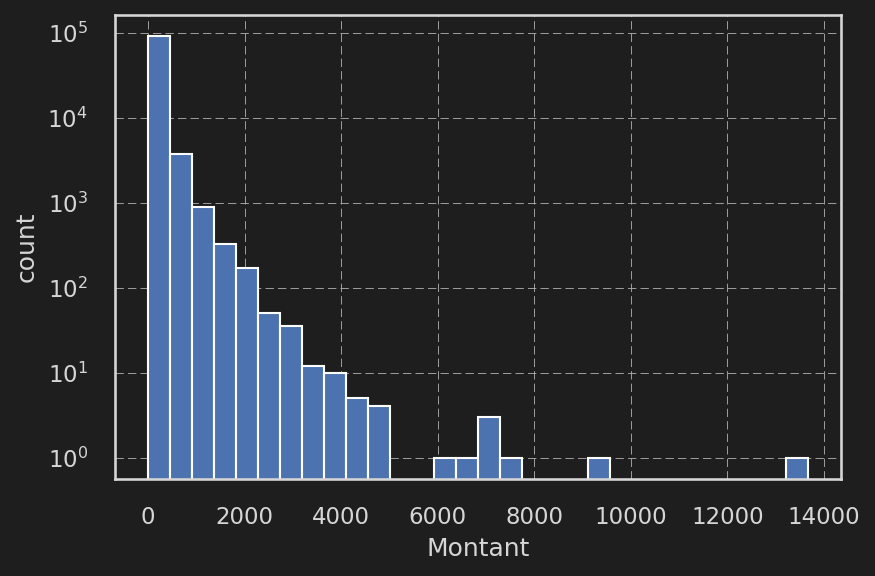

In [160]:
fig, ax = plt.subplots( figsize=(6,4) )

df_model.hist( column='Montant', bins=30, ax=ax )
ax.set_yscale( 'log' )
ax.set_title('')
ax.set_xlabel('Montant')
ax.set_ylabel('count')
fig.tight_layout()
savefig( fig, path_print + 'Montant' )

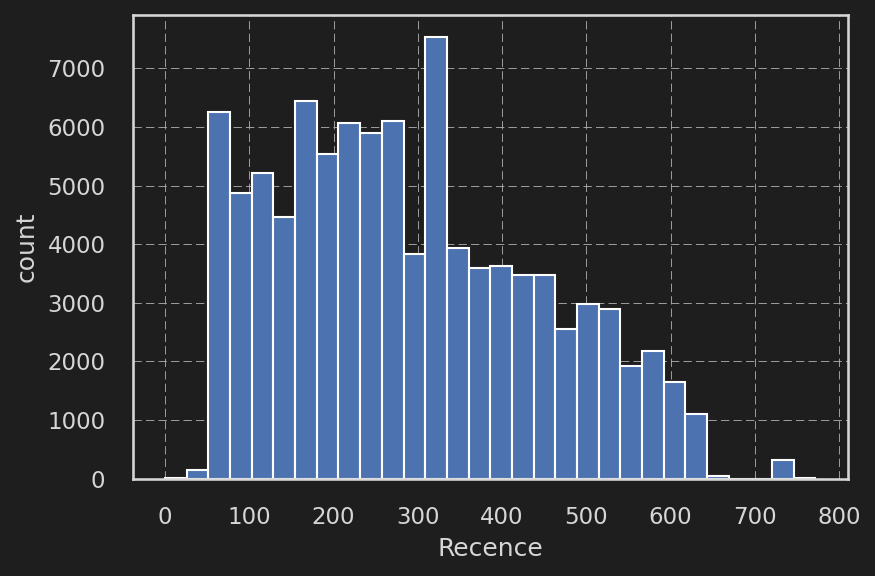

In [161]:
fig, ax = plt.subplots( figsize=(6,4) )

df_model.hist( column='Recence', bins=30, ax=ax )
ax.set_title('')
ax.set_xlabel('Recence')
ax.set_ylabel('count')
fig.tight_layout()
savefig( fig, path_print + 'Recence' )

Utilisation de quantiles

Pair plot :

La seule corrélation visible est entre les variables "Montant" et "Frequence".

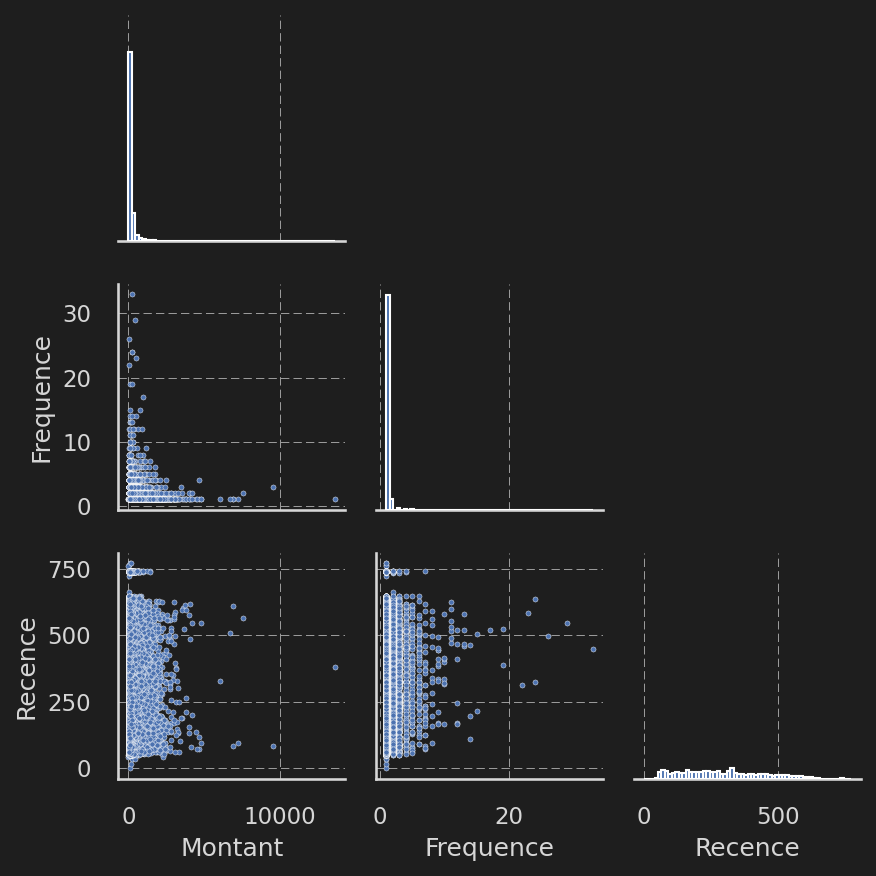

In [164]:
sort_order = ['Montant','Frequence', 'Recence']

# g = sns.pairplot( data=df_model, vars=sort_order,
#         plot_kws={'s':6}, diag_kind='auto', corner=True )

g = sns.PairGrid(df_model, vars=sort_order,corner=True, height=2)
g.map_diag(plt.hist, bins=60)
g.map_lower(sns.scatterplot, s=6)

# print( g.axes[0][0].get_ylim())
# g.axes[0][0].autoscale()
# g.axes[0][0].relim()
# print( g.axes[0][0].get_ylim())
# handles = g._legend_data.values()
# labels = g._legend_data.keys()
# g.fig.legend(handles=handles, labels=labels, loc=[0.2,0.65], ncol=1)
# g.legend.remove()
# g.fig.suptitle('linear values')
g.fig.tight_layout()

# savefig( g.fig, path_print + 'pair_plot' ) # ! file larger than initial ??
g.fig.savefig( path_print + 'pair_plot.png' )

## Analyse par quantiles

categories Frequence: Int64Index([1, 2, 3], dtype='int64')
categories Montant: Int64Index([1, 2, 3], dtype='int64')
categories Recence: Int64Index([1, 2, 3], dtype='int64')


,Recence,Frequence,Montant
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,3,1,2
0000b849f77a49e4a4ce2b2a4ca5be3f,3,1,1
0000f46a3911fa3c0805444483337064,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,1,1,1
0004aac84e0df4da2b147fca70cf8255,2,1,3


<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Recence    96096 non-null  category
 1   Frequence  96096 non-null  category
 2   Montant    96096 non-null  category
dtypes: category(3)
memory usage: 3.0+ MB


None

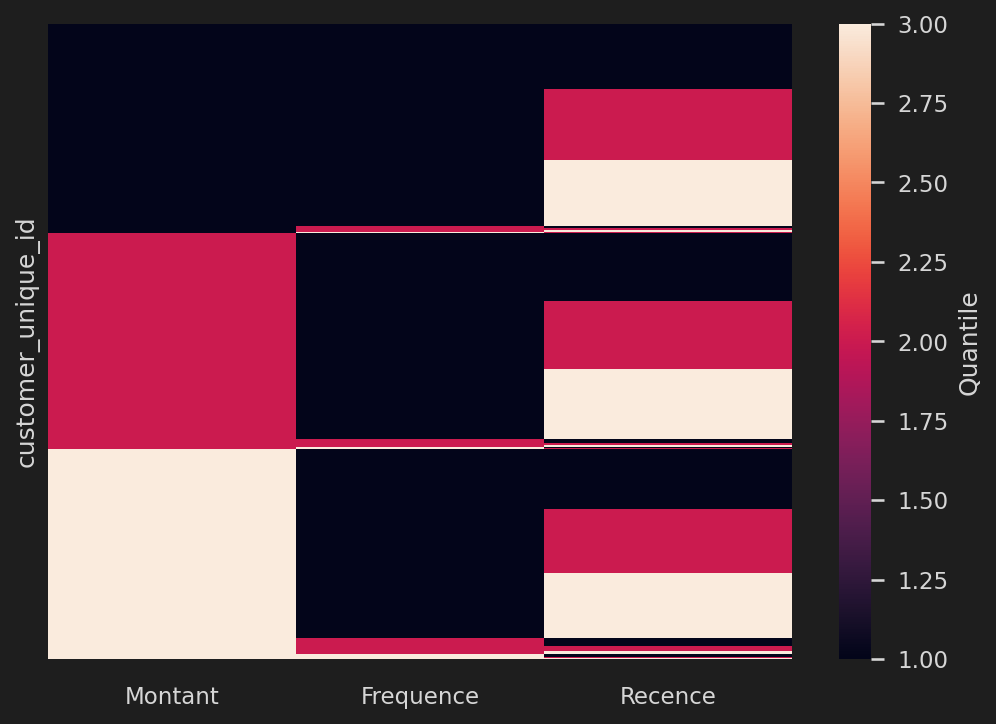

In [134]:
df_quantiles = df_model.copy()

# Frequence
key = 'Frequence'
# loc = df_quantiles[key] != 1
# sr = df_quantiles.loc[loc,key]
# print('sr:', sr.min(), sr.max())
# print( sr.quantile([0.3, 0.9]) )
# categs = np.digitize( sr.values,bins=sr.quantile([0.3, 0.6]))
# print( categs.min(), categs.max() )
# df_quantiles.loc[loc,key] = np.digitize( df_quantiles.loc[loc,key].values,bins=[3])

# On laisse les valeurs 1 et 2 telles quelles, les autres (> 2) sont en catégorie 3
df_quantiles.loc[ df_quantiles[key]>2, key] = 3
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )


key = 'Montant'
quantiles = df_quantiles[key].quantile( [0.33, 0.67] )
# print(quantiles)
categs = np.digitize( df_quantiles[key].values, bins=quantiles )
# print('categs:', categs.min(), categs.max() )
df_quantiles[key] = 1 + categs
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )


key = 'Recence'
quantiles = df_quantiles[key].quantile( [0.33, 0.67] )
# print(quantiles)
categs = np.digitize( df_quantiles[key].values, bins=quantiles )
# print('categs:', categs.min(), categs.max() )
df_quantiles[key] = 3 - categs
df_quantiles[key] = df_quantiles[key].astype('category')
print( f'categories {key}:', df_quantiles[key].cat.categories )


ax = sns.heatmap( df_quantiles[sort_order].astype('float').sort_values( by=sort_order ) ,
            cbar_kws={'label': 'Quantile'})
ax.set_yticks([])

display( df_quantiles.head(5) )
display( df_quantiles.info() )

Calcul score RFM

In [135]:
# def calc_RFM( row ):
#     return '{:}{:}{:}'.format( *row )

# df_quantiles['RFM'] = df_quantiles['Recence', 'Frequence', 'Monant'].apply( calc_RFM, axis=1 )
df_quantiles['RFM'] = df_quantiles['Recence'].astype(str) + df_quantiles['Frequence'].astype(str) + df_quantiles['Montant'].astype(str)

df_quantiles.head(5)

,Recence,Frequence,Montant,RFM
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,3,1,2,312
0000b849f77a49e4a4ce2b2a4ca5be3f,3,1,1,311
0000f46a3911fa3c0805444483337064,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,1,1,1,111
0004aac84e0df4da2b147fca70cf8255,2,1,3,213


Usual categories of custormers using RFM score:

| categorie | RFM | Description |
| :--- | :--- | :---: |
| Best Customers | 333 | Achats récents, fréquents, et dépenses importantes |
| Loyal Customers | 33x | Achats récents et fréquents |
| Almost Lost | 233 | Plus d'achats depuis quelques temps, mais a acheté fréquemment et dépensé beaucoup |
| Lost Customers | 133 | Plus d'achats depuis longtemps, mais a acheté fréquemment et dépensé beaucoup  |
| Big Spenders |  XX3 | Dépenses importantes |
| Lost Cheap Customers | 111 | Achats anciens, peu fréquents et petit montants |


In [166]:
segment_mapping = {
    r'[3][3][3]': 'Best',
    r'[3][3][1-2]': 'Loyal',
    r'[3][1-2][0-9]': 'New',
    

    r'[2][3][0-9]': 'Almost Lost',
    r'[2][2][0-9]': 'Potentially Loyal',
    
    r'[1-2][1][0-9]': 'One Shot',
    r'[1][2-3][0-9]': 'Lost',
}

df_model['RFM' ] = df_quantiles['RFM']
df_model['Segment'] = df_quantiles['RFM'].replace( segment_mapping, regex=True )

# check all mapped
print('number of entries:', len(df_model) )
is_converted = pd.to_numeric( df_model['Segment'], errors='coerce' ).isna()
print( 'number of converted:', is_converted.sum() )
# display( df_model.loc[ ~is_converted, : ] )

display( df_model.head(10).style.set_caption( 'head of the DataFrame') )
df_model.drop( columns='RFM', inplace=True )

number of entries: 96096
number of converted: 96096


,Recence,Frequence,Montant,RFM,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.900000,312,New
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.190000,311,New
0000f46a3911fa3c0805444483337064,585,1,86.220000,112,One Shot
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.620000,111,One Shot
0004aac84e0df4da2b147fca70cf8255,336,1,196.890000,213,One Shot
0004bd2a26a76fe21f786e4fbd80607f,194,1,166.980000,313,New
00050ab1314c0e55a6ca13cf7181fecf,180,1,35.380000,311,New
00053a61a98854899e70ed204dd4bafe,231,1,419.180000,213,One Shot
0005e1862207bf6ccc02e4228effd9a0,591,1,150.120000,112,One Shot


In [137]:
groups = df_model.groupby( by='Segment' )
df_RFM_segments = groups.agg( ['min', 'max', 'mean'] )
for key in ['Recence', 'Frequence', 'Montant']:
    df_RFM_segments[ (key, 'mean') ] = df_RFM_segments[ (key, 'mean') ].round(2)
df_RFM_segments['count'] = groups['Recence'].agg('count')
df_RFM_segments['count (%)'] = (df_RFM_segments['count'] * ( 100 / len(df_model) )).round(2)

display(df_RFM_segments)

prop_New_One_Shot = df_RFM_segments.loc[['One Shot', 'New'], 'count (%)' ].sum()
print('{:.2f}% are "New" or "One Shot"'.format( prop_New_One_Shot ) )

n_F_sup_1 = (df_model['Frequence'] > 1).sum()
print( f'{n_F_sup_1/len(df_model):.2%} bought more than once' )

Recence              Frequence           Montant            \
                      min  max    mean       min max  mean     min       max   
Segment                                                                        
Almost Lost           200  345  270.89         3  24  3.82   19.07   2486.01   
Best                   49  199  123.60         3  14  3.85  154.15   9553.02   
Lost                  346  744  476.69         2  33  2.53   16.05   7571.63   
Loyal                  50  198  130.40         3  14  4.14   17.38    151.10   
New                     0  199  125.57         1   2  1.03    0.00   7274.88   
One Shot              200  772  370.13         1   1  1.00    0.00  13664.08   
Potentially Loyal     200  345  273.51         2   2  2.00   16.37   3297.40   

                           count count (%)  
                     mean                   
Segment                                     
Almost Lost        322.40    413      0.43  
Best               552.66     96      0.10  
Lost               266.73   2622      2.73  
Loyal               85.24    125      0.13  
New                168.01  31466     32.74  
One Shot           159.65  59866     62.30  
Potentially Loyal  225.97   1508      1.57

95.04% are "New" or "One Shot"
6.04% bought more than once


## Analyse de variables supplémentaires

Review score

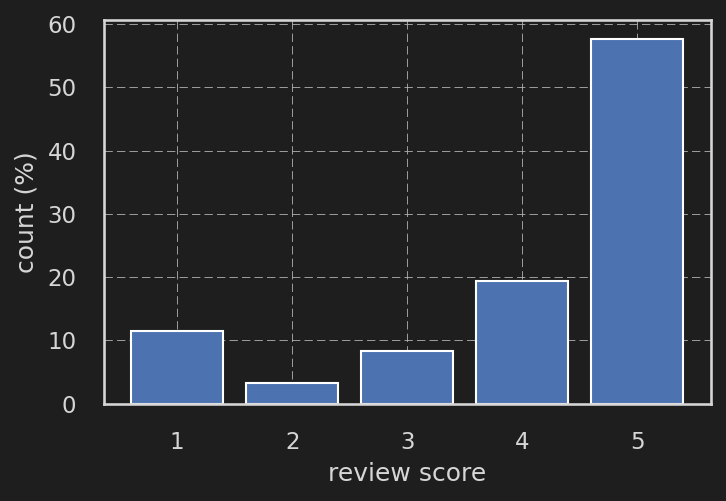

In [138]:
fig, ax = plt.subplots( figsize=(5,3.5) )
tmp = 100*df_merged['review_score'].value_counts( normalize=True )
ax.bar( tmp.index.values, tmp )
ax.set_xlabel('review score')
ax.set_ylabel('count (%)')
fig.tight_layout()

fig.tight_layout()
savefig( fig, path_print + 'review_score' )

Retard de livraison

In [139]:
loc = df_merged['order_status'] == 'delivered'

key = 'delivery_time'
df_merged[key] = np.nan
df_merged.loc[ loc, key ] = df_merged.loc[ loc, 'order_delivered_customer_date' ] - df_merged.loc[ loc, 'order_purchase_timestamp' ]

key = 'estimated_delivery_time'
df_merged[key] = np.nan
df_merged.loc[ loc, key ] = df_merged.loc[ loc, 'order_estimated_delivery_date' ] - df_merged.loc[ loc, 'order_purchase_timestamp' ]

# DELIVRY DELAY, EXPRESSED IN HOURS
key = 'delivery_delay'
df_merged[key] = np.nan
delay = df_merged.loc[ loc, 'delivery_time' ] - df_merged.loc[ loc, 'estimated_delivery_time']
df_merged.loc[ loc, key ] = 24*delay.dt.days + delay.dt.seconds/3600

df_merged.sample( 10 )

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,estimated_delivery_time,delivery_delay
76824,0f3d5c4023c13c415b24e755cbe72fab,a9e5f310be41efa00690d727bf672cab,delivered,2017-12-15 12:20:46,2017-12-15 12:32:50,2017-12-16 18:36:01,2017-12-26 17:59:06,2018-01-11,3de7fd0b0d84bf1f9e653b8f00f175cf,50721,recife,PE,1.0,credit_card,4.0,148.18,e0e63876c7320b0fc16e5954583bfb0e,5.0,NaN,NaN,2017-12-27 00:00:00,2017-12-27 20:37:33,11 days 05:38:20,26 days 11:39:14,-366.015000
37081,9a1868b5b95ed88747fa160701bf6d8f,76446677a46e1f51a0f01371e3f46bdc,delivered,2018-06-18 16:17:47,2018-06-18 17:01:27,2018-06-20 14:24:00,2018-06-22 20:28:30,2018-07-05,c4b1e5c06add0388a2d181248f4c3a3e,13574,sao carlos,SP,1.0,credit_card,6.0,123.75,3a86ac923cc02c13c74c807d739891ea,5.0,NaN,NaN,2018-06-23 00:00:00,2018-06-25 17:22:44,4 days 04:10:43,16 days 07:42:13,-291.525000
39806,945dd5fdb173f89e1e87a833291b468e,eadaeca94cdf0c4d48a937d43155953b,delivered,2018-02-27 21:07:07,2018-02-27 21:15:43,2018-03-01 14:44:42,2018-03-08 21:01:51,2018-03-19,8f701c9efe7079f425c94d34b0b533ce,13160,artur nogueira,SP,1.0,credit_card,1.0,28.75,80b2834d5ee87e9754ac7f1564d83d30,5.0,NaN,NaN,2018-03-09 00:00:00,2018-03-10 00:39:49,8 days 23:54:44,19 days 02:52:53,-242.969167
104203,0d3030480b6641db146fb663f52a6d0a,a28ffb71674bd7b87ec0765cb21cbe7b,delivered,2018-03-01 07:23:38,2018-03-02 07:29:04,2018-03-10 00:11:31,2018-03-19 22:51:44,2018-03-21,a39c967d9cc336e258954dc444525d51,13566,sao carlos,SP,1.0,credit_card,8.0,290.60,75f004ae64be0be0602be348554b04fb,5.0,NaN,O produto é bom e foi entregue no prazo previsto,2018-03-20 00:00:00,2018-03-22 13:01:03,18 days 15:28:06,19 days 16:36:22,-25.137778
88675,505ad05b659736f51f674522b701d9a5,496e44431a2a9a6be2eabb10d3ffa24a,delivered,2017-09-20 21:07:28,2017-09-20 21:15:29,2017-09-21 16:33:12,2017-10-24 14:28:42,2017-10-16,5026a05d38ac5cde9dfc41a3269f8b04,3980,sao paulo,SP,1.0,credit_card,1.0,75.08,7b5e6f6a5fd4bdb9eabc2df825bf0731,1.0,NaN,Nao recomendo pois não recebi o produto e tamb...,2017-10-18 00:00:00,2017-10-18 03:42:49,33 days 17:21:14,25 days 02:52:32,206.478333
46247,143a94013dbe03feb57f03420bd2bd15,b6cf52fb9b2493744df19612952a2580,delivered,2018-07-20 20:35:46,2018-07-20 20:50:13,2018-07-24 12:43:00,2018-07-25 16:18:50,2018-07-30,b8b3ca36a32f331773421785348bb956,8440,sao paulo,SP,1.0,credit_card,1.0,34.35,4c31f8f61955d1d9376165c1f673c18f,5.0,NaN,NaN,2018-07-26 00:00:00,2018-07-26 22:49:04,4 days 19:43:04,9 days 03:24:14,-103.686111
76641,637b8707a779cf11512f479310e5751a,c58b1ad8b8cdbaecaea2e6c45385cdf2,delivered,2018-07-09 17:14:04,2018-07-10 12:25:11,2018-07-11 11:53:00,2018-07-17 18:28:37,2018-07-26,f45ff20176b28f1af7fe3e10eab1ce76,88010,florianopolis,SC,1.0,boleto,1.0,54.37,d0debfd813b293b9bfb1d2cb4d5e4e64,5.0,10,Muito legal,2018-07-28 00:00:00,2018-07-30 10:39:06,8 days 01:14:33,16 days 06:45:56,-197.523056
57087,33d1c541fe62cc7e7de82f1a6f7209f1,4da02003088ff69e3a0ae3db17d648f6,delivered,2018-07-05 19:45:19,2018-07-05 19:55:13,2018-07-06 10:04:00,2018-07-11 22:33:46,2018-07-24,3d93772915efa454a89bf52047b0b285,32050,contagem,MG,1.0,credit_card,1.0,96.05,1b9df9431f02e14c822ca6bed96f54ed,5.0,NaN,NaN,2018-07-12 00:00:00,2018-07-13 14:16:06,6 days 02:48:27,18 days 04:14:41,-289.437222
83543,667e8016c1467476000d4dde127343ac,99a1ce52801276a0468c5dc65cf77280,delivered,2017-09-19 14:27:33,2017-09-19 14:44:25,2017-09-21 21:00:31,2017-10-10 17:12:41,2017-10-13,f3b75d6f1b2a6555223b35fcb52dcf54,88705,tubarao,SC,1.0,credit_card,4.0,65.10,83d44a9211bb830054a068c60a6f7b74,5.0,NaN,NaN,2017-10-11 00:00:00,2017-10-12 11:05:57,21 days 02:45:08,23 days 09:32:27,-54.788611

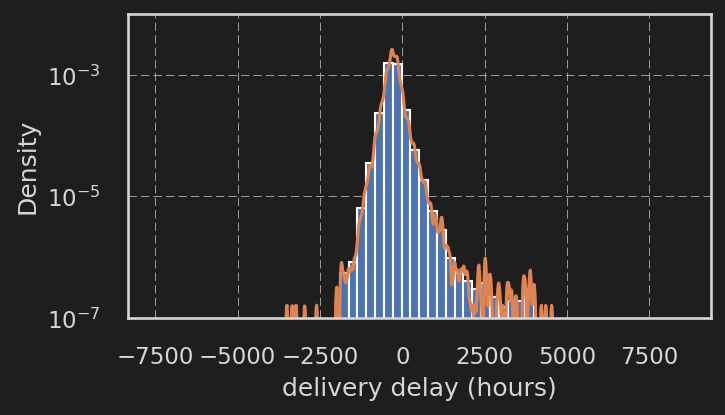

In [140]:
fig, ax = plt.subplots( figsize=(5,3) )
a, b, c = ax.hist( df_merged['delivery_delay'], bins=30, density=True )
df_merged['delivery_delay'].plot( kind='density', ax=ax )
ax.set_yscale( 'log' )
ax.set_ylim( [1e-7, 1e-2])
ax.set_xlabel( 'delivery delay (hours)' )

fig.tight_layout()
savefig( fig, path_print + 'delivery_delay' )

Type de paiement

count (%):


credit_card    73.889947
boleto         19.056826
voucher         5.580176
debit_card      1.470180
not_defined     0.002871
Name: payment_type, dtype: float64

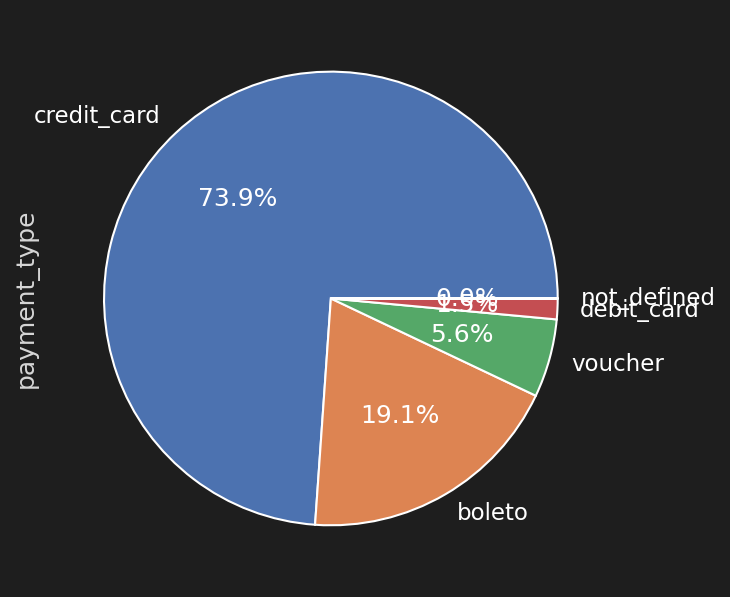

In [141]:
value_count = df_merged['payment_type'].value_counts()
ax = value_count.plot( kind='pie', autopct='%1.1f%%', figsize=(5,5) )

fig = ax.get_figure()
fig.tight_layout()
savefig( fig, path_print + 'payment_type' )

print('count (%):')
display( value_count * (100 / value_count.sum() ) )